In [1]:

import os
import re
import glob
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from PNW_cmap import PNW_cmap
from vip_slap2_analysis.utils.utils import save_figure, normalize
from vip_slap2_analysis.io.session_registry import VIPSessionRegistry

import seaborn as sns
sns.set_style('white')
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'xx-large',
         'axes.titlesize':'xx-large',
         'xtick.labelsize':'xx-large',
         'ytick.labelsize':'xx-large'}
plt.rcParams.update(params)

from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

In [2]:
%load_ext autoreload
%autoreload 2

%matplotlib notebook

### Helper Functions

In [3]:
import os
import glob
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


def parse_dmd_label(dmd_key):
    """
    Return integer DMD number for keys like 'DMD1', 'dmd2', or 1/2.
    Return None for non-DMD keys like 'metadata'.
    """
    if isinstance(dmd_key, (int, np.integer)):
        return int(dmd_key)

    s = str(dmd_key).strip()
    m = re.fullmatch(r"dmd(\d+)", s, flags=re.IGNORECASE)
    if m:
        return int(m.group(1))

    if s.isdigit():
        return int(s)

    return None


def get_session_id_from_asset(asset):
    return asset.session_id


def load_mean_tuning_curves_from_assets(
    assets,
    image_order=None,
    sort_images=True,
):
    rows = []

    for asset in assets:
        session_id = get_session_id_from_asset(asset)

        npz_matches = glob.glob(
            os.path.join(asset.derived_dir, "**", "glutamate_mean_df.npz"),
            recursive=True,
        )
        if len(npz_matches) == 0:
            print(f"Skipping {session_id}: no glutamate_mean_df.npz found")
            continue

        npz_path = npz_matches[0]
        data = np.load(npz_path, allow_pickle=True)["data"][0]

        for top_key in data.keys():
            dmd_num = parse_dmd_label(top_key)
            if dmd_num is None:
                continue

            dmd_data = data[top_key]

            if "synapse_ids" not in dmd_data or "image_identity" not in dmd_data:
                print(f"Skipping {session_id} {top_key}: missing synapse_ids or image_identity")
                continue

            syn_ids = np.asarray(dmd_data["synapse_ids"]).astype(str)
            image_dict = dmd_data["image_identity"]

            if image_order is None:
                im_names = list(image_dict.keys())
                if sort_images:
                    im_names = sorted(im_names)
            else:
                im_names = [im for im in image_order if im in image_dict]

            if len(im_names) == 0:
                print(f"Skipping {session_id} DMD{dmd_num}: no image names found")
                continue

            synapse_curves = {syn_id: [] for syn_id in syn_ids}
            n_timepoints = None

            for im_name in im_names:
                im_data = np.asarray(image_dict[im_name]["mean"])

                if im_data.ndim != 2:
                    raise ValueError(
                        f"{session_id} DMD{dmd_num} image {im_name}: expected 2D array, got {im_data.shape}"
                    )

                if im_data.shape[0] != len(syn_ids):
                    raise ValueError(
                        f"{session_id} DMD{dmd_num} image {im_name}: "
                        f"first axis {im_data.shape[0]} != n_synapse_ids {len(syn_ids)}"
                    )

                if n_timepoints is None:
                    n_timepoints = im_data.shape[1]
                elif im_data.shape[1] != n_timepoints:
                    raise ValueError(
                        f"{session_id} DMD{dmd_num} image {im_name}: "
                        f"inconsistent timepoints {im_data.shape[1]} vs expected {n_timepoints}"
                    )

                for i, syn_id in enumerate(syn_ids):
                    synapse_curves[syn_id].append(np.asarray(im_data[i], dtype=float))

            depth = np.nan
            session_type = np.nan
            if hasattr(asset, "metadata") and asset.metadata is not None:
                depth = asset.metadata.get(f"dmd{dmd_num}_depth", np.nan)
                session_type = asset.metadata.get("session_type", np.nan)

            for syn_id, pieces in synapse_curves.items():
                if len(pieces) != len(im_names):
                    continue

                tuning_curve = np.concatenate(pieces, axis=0)

                rows.append(
                    {
                        "session_id": str(session_id),
                        "dmd": int(dmd_num),
                        "depth": depth,
                        "session_type": session_type,
                        "synapse_id": str(syn_id),
                        "n_images": len(im_names),
                        "n_timepoints_per_image": int(n_timepoints),
                        "curve_length": int(len(tuning_curve)),
                        "image_order": tuple(im_names),
                        "tuning_curve": tuning_curve,
                    }
                )

    pca_df = pd.DataFrame(rows)

    if not pca_df.empty:
        pca_df["session_id"] = pca_df["session_id"].astype(str)
        pca_df["dmd"] = pca_df["dmd"].astype(int)
        pca_df["synapse_id"] = pca_df["synapse_id"].astype(str)

    return pca_df


def build_activation_labels(assets):
    rows = []

    for asset in assets:
        session_id = get_session_id_from_asset(asset)

        matches = glob.glob(
            os.path.join(asset.derived_dir, "**", "activation_summary_table.parquet"),
            recursive=True,
        )
        if len(matches) == 0:
            continue

        df = pd.read_parquet(matches[0]).copy()
        if df.empty:
            continue

        df["session_id"] = str(session_id)

        if "dmd" not in df.columns or "synapse_id" not in df.columns:
            continue

        df["dmd"] = df["dmd"].apply(parse_dmd_label)
        df = df[df["dmd"].notna()].copy()
        df["dmd"] = df["dmd"].astype(int)
        df["synapse_id"] = df["synapse_id"].astype(str)

        if "response_class" not in df.columns:
            df["response_class"] = np.nan

        rows.append(df[["session_id", "dmd", "synapse_id", "response_class"]])

    if len(rows) == 0:
        return pd.DataFrame(columns=["session_id", "dmd", "synapse_id", "response_class"])

    out = pd.concat(rows, ignore_index=True)
    out = out.drop_duplicates(subset=["session_id", "dmd", "synapse_id"])
    return out

### Load session summary table

In [4]:
basepath = r"\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics"
savepath = r"C:\Users\andrew.shelton\Dropbox\allen institute\Documents\Presentations\OPhys\Data_Club\April2026\figures"
summary_path = glob.glob(os.path.join(basepath,'**summary.xlsx'))[0]
summary_df = pd.read_excel(summary_path,sheet_name='subjects')
session_df = pd.read_excel(summary_path,sheet_name='sessions')

### Generate asset registry

In [5]:
target_mice = [
    803496,
    804730,804733,810196,
    809047,803121,
    826033,838410,834788
]

registry = VIPSessionRegistry.from_basepath(
    r'\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics'
)

process_df = registry.sessions(
    subject_ids=target_mice,
    exclude_session_types=["expression_check", "volume_imaging"],
    paradigms=["change_detection_passive"],
)

assets = [registry.resolve_assets(row) for _, row in process_df.iterrows()]

print(f"Loaded {len(assets)} session assets")

Loaded 56 session assets


In [6]:
assets[0]

SessionAssets(session_id='803496_2025-07-25_13-02-10', subject_id=803496, session_dir=WindowsPath('//allen/aind/scratch/ophys/Andrew/VIP_synaptic_dynamics/iGluSnFR4f/803496/2025-07-25_803496'), summary_mat=WindowsPath('//allen/aind/scratch/ophys/Andrew/VIP_synaptic_dynamics/iGluSnFR4f/803496/2025-07-25_803496/803496_2025-07-25_13-02-10_slap2_2026-01-18_05-53-08/source_extraction/ExperimentSummary/SummaryLoCo-260117-185357.mat'), bonsai_event_log_csv=WindowsPath('//allen/aind/scratch/ophys/Andrew/VIP_synaptic_dynamics/iGluSnFR4f/803496/2025-07-25_803496/803496_2025-07-25_13-02-10/behavior/VCO1_Behavior.harp/bonsai_event_log.csv'), harp_dir=WindowsPath('//allen/aind/scratch/ophys/Andrew/VIP_synaptic_dynamics/iGluSnFR4f/803496/2025-07-25_803496/803496_2025-07-25_13-02-10/behavior/VCO1_Behavior.harp'), photodiode_pkl=WindowsPath('//allen/aind/scratch/ophys/Andrew/VIP_synaptic_dynamics/iGluSnFR4f/803496/2025-07-25_803496/803496_2025-07-25_13-02-10/behavior/VCO1_Behavior.harp/extracted_files

### Load session data and build concatenated tuning curves


In [7]:
pca_df = load_mean_tuning_curves_from_assets(assets)
print(f"Loaded {len(pca_df)} synapse tuning curves")
pca_df.head()

Loaded 6992 synapse tuning curves


,session_id,dmd,depth,session_type,synapse_id,n_images,n_timepoints_per_image,curve_length,image_order,tuning_curve
0,803496_2025-07-25_13-02-10,1,25,familiar,DMD1_syn0000,7,150,1050,"(stimuli\images_A\imk00459.tiff, stimuli\image...","[12.293905368000678, 12.216543272815091, 11.88..."
1,803496_2025-07-25_13-02-10,1,25,familiar,DMD1_syn0001,7,150,1050,"(stimuli\images_A\imk00459.tiff, stimuli\image...","[9.19650692698164, 9.297651751750449, 9.603456..."
2,803496_2025-07-25_13-02-10,1,25,familiar,DMD1_syn0002,7,150,1050,"(stimuli\images_A\imk00459.tiff, stimuli\image...","[9.8938959003393, 9.965805901286249, 10.406103..."
3,803496_2025-07-25_13-02-10,1,25,familiar,DMD1_syn0003,7,150,1050,"(stimuli\images_A\imk00459.tiff, stimuli\image...","[8.89703385242744, 8.777619254661456, 8.195837..."
4,803496_2025-07-25_13-02-10,1,25,familiar,DMD1_syn0004,7,150,1050,"(stimuli\images_A\imk00459.tiff, stimuli\image...","[12.34948151424674, 12.82996975128414, 12.7776..."


In [8]:
print(pca_df["curve_length"].describe())

display(
    pca_df.groupby(["session_id", "dmd"])
    .size()
    .reset_index(name="n_synapses")
    .head(20)
)

example = pca_df.iloc[0]
print(
    f"Example: session={example.session_id}, dmd={example.dmd}, "
    f"synapse={example.synapse_id}, curve_length={example.curve_length}, "
    f"n_images={example.n_images}"
)

count    6992.0
mean     1050.0
std         0.0
min      1050.0
25%      1050.0
50%      1050.0
75%      1050.0
max      1050.0
Name: curve_length, dtype: float64


,session_id,dmd,n_synapses
0,803121_2025-10-29_11-19-29,1,37
1,803121_2025-10-29_11-19-29,2,39
2,803121_2025-10-30_11-13-32,1,90
3,803121_2025-10-30_11-13-32,2,57
4,803121_2025-10-31_13-05-26,1,126
5,803121_2025-10-31_13-05-26,2,69
6,803121_2025-11-01_19-00-21,1,63
7,803121_2025-11-01_19-00-21,2,101
8,803121_2025-11-05_11-16-57,1,96
9,803121_2025-11-05_11-16-57,2,57


Example: session=803496_2025-07-25_13-02-10, dmd=1, synapse=DMD1_syn0000, curve_length=1050, n_images=7


In [9]:
pca_df.session_id.unique()

array(['803496_2025-07-25_13-02-10', '803496_2025-07-28_08-04-39',
       '803496_2025-07-29_13-34-35', '803496_2025-07-30_10-05-23',
       '803496_2025-07-31_09-43-28', '803496_2025-08-01_13-22-49',
       '804730_2025-07-25_14-08-35', '804730_2025-07-28_13-57-34',
       '804730_2025-07-29_14-55-04', '804730_2025-07-30_11-11-11',
       '804730_2025-07-31_11-45-27', '804730_2025-08-01_14-22-38',
       '804733_2025-07-25_15-17-00', '804733_2025-07-28_19-00-06',
       '804733_2025-07-29_16-02-24', '804733_2025-07-30_12-59-44',
       '804733_2025-07-31_13-29-01', '804733_2025-08-01_15-20-32',
       '810196_2025-07-25_16-24-20', '810196_2025-07-28_19-59-05',
       '810196_2025-07-29_17-02-41', '810196_2025-07-31_08-28-08',
       '810196_2025-07-31_14-19-46', '810196_2025-08-01_16-37-27',
       '809047_2025-10-29_10-16-32', '809047_2025-10-30_10-06-43',
       '809047_2025-10-31_12-00-50', '809047_2025-11-01_17-51-59',
       '809047_2025-11-05_10-13-00', '809047_2025-11-06_11-05-

In [10]:
print("n assets:", len(assets))
print("n unique sessions:", pca_df["session_id"].nunique())
print("n unique session/DMD pairs:", pca_df[["session_id", "dmd"]].drop_duplicates().shape[0])

n assets: 56
n unique sessions: 56
n unique session/DMD pairs: 112


In [11]:
activation_df = build_activation_labels(assets)

pca_df = pca_df.merge(
    activation_df,
    on=["session_id", "dmd", "synapse_id"],
    how="left",
)

pca_df.head()

,session_id,dmd,depth,session_type,synapse_id,n_images,n_timepoints_per_image,curve_length,image_order,tuning_curve,response_class
0,803496_2025-07-25_13-02-10,1,25,familiar,DMD1_syn0000,7,150,1050,"(stimuli\images_A\imk00459.tiff, stimuli\image...","[12.293905368000678, 12.216543272815091, 11.88...",no_change
1,803496_2025-07-25_13-02-10,1,25,familiar,DMD1_syn0001,7,150,1050,"(stimuli\images_A\imk00459.tiff, stimuli\image...","[9.19650692698164, 9.297651751750449, 9.603456...",no_change
2,803496_2025-07-25_13-02-10,1,25,familiar,DMD1_syn0002,7,150,1050,"(stimuli\images_A\imk00459.tiff, stimuli\image...","[9.8938959003393, 9.965805901286249, 10.406103...",activated
3,803496_2025-07-25_13-02-10,1,25,familiar,DMD1_syn0003,7,150,1050,"(stimuli\images_A\imk00459.tiff, stimuli\image...","[8.89703385242744, 8.777619254661456, 8.195837...",activated
4,803496_2025-07-25_13-02-10,1,25,familiar,DMD1_syn0004,7,150,1050,"(stimuli\images_A\imk00459.tiff, stimuli\image...","[12.34948151424674, 12.82996975128414, 12.7776...",deactivated


### Optional filtering by session, DMD, depth, or session type

In [12]:
pca_plot_df = pca_df.copy()

# Examples:
# pca_plot_df = pca_plot_df[pca_plot_df["session_type"] == "familiar"]
# pca_plot_df = pca_plot_df[pca_plot_df["depth"].isin([25, 100])]
# pca_plot_df = pca_plot_df[pca_plot_df["dmd"] == 1]

print(f"N curves after filtering: {len(pca_plot_df)}")

N curves after filtering: 6992


### Run PCA on full concatenated tuning curves

In [18]:
X = np.stack(pca_plot_df["tuning_curve"].to_numpy())

scaler = StandardScaler(with_mean=True, with_std=True)
Xz = scaler.fit_transform(X)

pca = PCA(n_components=11)
Xpca = pca.fit_transform(Xz)

pca_plot_df = pca_plot_df.copy()
pca_plot_df["PC1"] = Xpca[:, 0]
pca_plot_df["PC2"] = Xpca[:, 1]
pca_plot_df["PC3"] = Xpca[:, 2]

print("X shape:", X.shape)
print("Explained variance ratio (first 10 PCs):")
print(pca.explained_variance_ratio_[:10])

X shape: (6992, 1050)
Explained variance ratio (first 10 PCs):
[0.87143266 0.03122351 0.01355713 0.00829668 0.00740828 0.00629753
 0.00557907 0.00469904 0.00427567 0.00347074]


### Explained Variance by PC

In [19]:
explained_var = pca.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

<IPython.core.display.Javascript object>


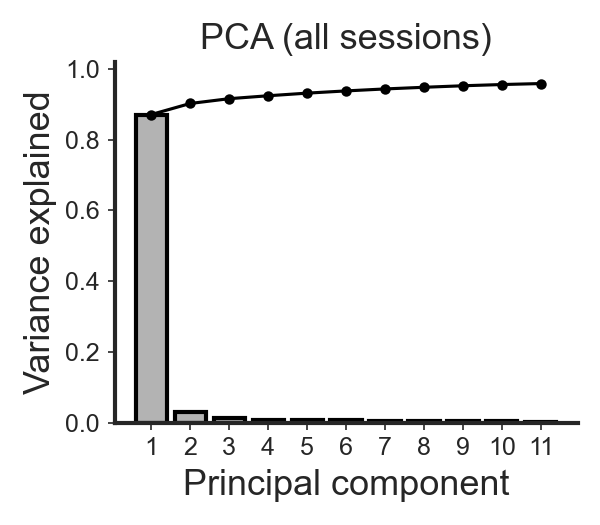

In [62]:
fig, ax = plt.subplots(figsize=(4, 3.5))
pcs = np.arange(1, len(explained_var) + 1)

ax.tick_params(axis='x', which='major', reset=True, top=False, labelsize=12)
ax.tick_params(axis='y', which='major', reset=True, right=False, labelsize=12)

ax.bar(pcs, explained_var, color='0.7', edgecolor='k',lw=2)
ax.plot(pcs, cumulative_var, 'o-', color='k', lw=1.5, ms=4)
ax.set_xlabel('Principal component')
ax.set_ylabel('Variance explained')
ax.set_xticks(pcs)
ax.set_ylim(0, 1.02)
ax.set_title('PCA (all sessions)')
sns.despine()

for spine in ['left','bottom']:
    ax.spines[spine].set_linewidth(2)

fig.tight_layout()

filen = 'PCA_explained_variance'
save_figure(fig,os.path.join(basepath,filen),formats=['.pdf','.png'],dpi=300)

### PC1 vs PC2 projection

In [66]:
def compute_curve_auc(curve, n_images, n_timepoints_per_image):
    """
    Mean baseline-subtracted AUC across images from the concatenated curve.
    Uses first third of image window as baseline and remainder as response window.
    """
    curve = np.asarray(curve, dtype=float)
    reshaped = curve.reshape(n_images, n_timepoints_per_image)

    baseline_end = n_timepoints_per_image // 3
    baseline = reshaped[:, :baseline_end].mean(axis=1, keepdims=True)
    auc = np.mean((reshaped - baseline),axis=1)
    return np.mean(auc)


pca_plot_df["mean_response_auc"] = [
    compute_curve_auc(curve, n_im, n_tp)
    for curve, n_im, n_tp in zip(
        pca_plot_df["tuning_curve"],
        pca_plot_df["n_images"],
        pca_plot_df["n_timepoints_per_image"],
    )
]

<IPython.core.display.Javascript object>


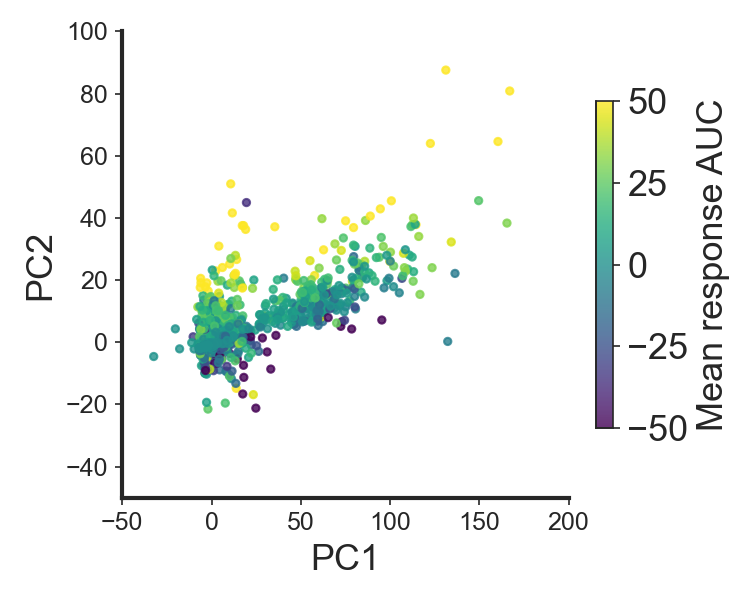

In [103]:
fig, ax = plt.subplots(figsize=(5, 4))

ax.tick_params(axis='x', which='major', reset=True, top=False, labelsize=12)
ax.tick_params(axis='y', which='major', reset=True, right=False, labelsize=12)

sc = ax.scatter(
    pca_plot_df["PC1"],
    pca_plot_df["PC2"],
    c=pca_plot_df["mean_response_auc"],
    cmap='viridis',
    vmin=-50,
    vmax=50,
    s=12,
    alpha=0.8,
)

cbar = plt.colorbar(sc, ax=ax,shrink=0.7)
cbar.set_label("Mean response AUC")

ax.set_xlim(-50,200)
ax.set_ylim(-50,100)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")

for spine in ['left','bottom']:
    ax.spines[spine].set_linewidth(2)

sns.despine()
fig.tight_layout()


filen = 'PC_scatter'
save_figure(fig,os.path.join(basepath,filen),formats=['.pdf','.png'],dpi=300)

### Color by depth or session type

<IPython.core.display.Javascript object>


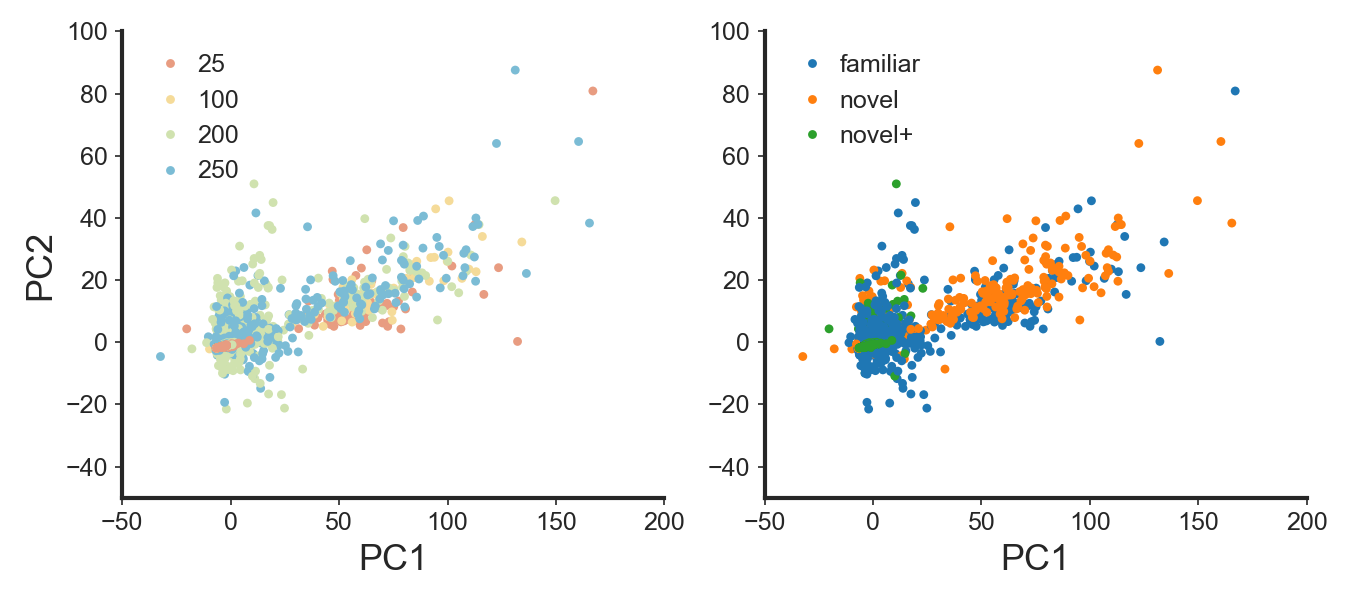

In [105]:

fig, axes = plt.subplots(1, 2, figsize=(9, 4), sharex=True, sharey=True)

depth_order = sorted([d for d in pca_plot_df['depth'].dropna().unique()])
if len(depth_order) > 0:
    _, _, depth_palette = PNW_cmap.get_PNW_cmap('Sailboat', n_colors=len(depth_order))
    depth_palette = depth_palette[::-1]
    depth_palette = {depth: depth_palette[i] for i, depth in enumerate(depth_order)}
else:
    depth_palette = None

sns.scatterplot(
    data=pca_plot_df,
    x='PC1', y='PC2',
    hue='depth',
    hue_order=depth_order if len(depth_order) > 0 else None,
    palette=depth_palette,
    s=18,
    linewidth=0,
    ax=axes[0],
)
axes[0].legend(loc='best',frameon=False,fontsize=12,handletextpad=0.1)

if 'session_type' in pca_plot_df.columns and pca_plot_df['session_type'].notna().any():
    sns.scatterplot(
        data=pca_plot_df,
        x='PC1', y='PC2',
        hue='session_type',
        s=18,
        linewidth=0,
        ax=axes[1],
    )
    axes[1].legend(loc='best',frameon=False,fontsize=12,handletextpad=0.1)
else:
    axes[1].scatter(plot_df['PC1'], plot_df['PC2'], s=18)
    axes[1].set_title('Session type unavailable')

for ax in axes:
    ax.tick_params(axis='x', which='major', reset=True, top=False, labelsize=12)
    ax.tick_params(axis='y', which='major', reset=True, right=False, labelsize=12)
    ax.set_xlim(-50,200)
    ax.set_ylim(-50,100)
    for spine in ['left','bottom']:
        ax.spines[spine].set_linewidth(2)
    sns.despine(ax=ax)

fig.tight_layout()

### ECDF of mean response AUC

In [132]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


def plot_response_auc_cdf_with_regions(
    df,
    value_col="mean_response_auc",
    class_col="response_class",
    class_order=("deactivated", "no change", "activated"),
    class_colors=None,
    xlim=None,
    ax=None,
):
    """
    Plot ECDF of a response metric with shaded regions corresponding to
    deactivated / no change / activated classes.

    Thresholds are inferred from the labeled data:
      left threshold  = max(value) among 'deactivated'
      right threshold = min(value) among 'activated'

    Parameters
    ----------
    df : pd.DataFrame
        Must contain value_col and class_col.
    value_col : str
        Column holding scalar response metric, e.g. mean_response_auc.
    class_col : str
        Column holding labels such as 'deactivated', 'no change', 'activated'.
    class_order : tuple[str]
        Expected ordering of the three classes.
    class_colors : dict or None
        Mapping from class label to shading color.
    xlim : tuple or None
        Optional x-axis limits.
    ax : matplotlib axis or None
    """
    if class_colors is None:
        class_colors = {
            "deactivated": "#4C66AF",
            "no change": "#D9D9D9",
            "activated": "#66B26F",
        }

    plot_df = df[[value_col, class_col]].copy()
    plot_df = plot_df.dropna(subset=[value_col, class_col])

    # Normalize common spelling variants
    plot_df[class_col] = (
        plot_df[class_col]
        .astype(str)
        .str.strip()
        .str.lower()
        .replace({
            "no-change": "no change",
            "no_change": "no change",
            "unchanged": "no change",
        })
    )

    needed = set(class_order)
    found = set(plot_df[class_col].unique())
    missing = needed - found
    if missing:
        raise ValueError(f"Missing expected classes: {missing}. Found: {sorted(found)}")

    deact_vals = plot_df.loc[plot_df[class_col] == "deactivated", value_col].to_numpy()
    nochange_vals = plot_df.loc[plot_df[class_col] == "no change", value_col].to_numpy()
    act_vals = plot_df.loc[plot_df[class_col] == "activated", value_col].to_numpy()

    if len(deact_vals) == 0 or len(act_vals) == 0:
        raise ValueError("Need at least one deactivated and one activated value to define thresholds.")

#     left_thr = np.nanmax(deact_vals)
#     right_thr = np.nanmin(act_vals)

    left_thr = -2
    right_thr = 5

    # Fallback in case labels overlap
    if left_thr > right_thr:
        # use midpoint between class medians as a conservative fallback
        left_thr = np.nanmedian(deact_vals)
        right_thr = np.nanmedian(act_vals)
        if left_thr > right_thr:
            left_thr, right_thr = sorted([left_thr, right_thr])

    all_vals = plot_df[value_col].to_numpy()
    xmin = np.nanmin(all_vals) if xlim is None else xlim[0]
    xmax = np.nanmax(all_vals) if xlim is None else xlim[1]

    if ax is None:
        fig, ax = plt.subplots(figsize=(4,5))
    else:
        fig = ax.figure

    # Shaded regions
    ax.axvspan(xmin, left_thr, color=class_colors["deactivated"], alpha=0.3, zorder=0)
    ax.axvspan(left_thr, right_thr, color=class_colors["no change"], alpha=0.3, zorder=0)
    ax.axvspan(right_thr, xmax, color=class_colors["activated"], alpha=0.3, zorder=0)

    # ECDF of all synapses
    sns.ecdfplot(
        data=plot_df,
        x=value_col,
        ax=ax,
        color='k',
        linewidth=2.5,zorder=10
    )

    # Threshold lines
    ax.axvline(left_thr, color="white", lw=2, alpha=0.95)
    ax.axvline(right_thr, color="white", lw=2, alpha=0.95)

    # Labels near top
    y_text = 1.02
    ax.text(
        (xmin + left_thr) / 2,
        y_text,
        "Deactivated",
        color=class_colors["deactivated"],
        rotation=30,
        ha="center",
        va="bottom",
        fontsize=14,
        fontweight="bold",
    )
    ax.text(
        (left_thr + right_thr) / 2,
        y_text,
        "No change",
        color="0.35",
        rotation=30,
        ha="center",
        va="bottom",
        fontsize=14,
        fontweight="bold",
    )
    ax.text(
        (right_thr + xmax) / 2,
        y_text,
        "Activated",
        color=class_colors["activated"],
        rotation=30,
        ha="center",
        va="bottom",
        fontsize=14,
        fontweight="bold",
    )

    ax.set_xlabel("Mean response A.U.C", fontsize=16)
    ax.set_ylabel("CDF", fontsize=16)
    ax.set_ylim(-0.02, 1.02)
    ax.set_xlim(xmin, xmax)

    ax.tick_params(axis="both", labelsize=12)
    ax.tick_params(axis='x', which='major', reset=True, top=False, labelsize=12)
    ax.tick_params(axis='y', which='major', reset=True, right=False, labelsize=12)
    for spine in ['left','bottom']:
        ax.spines[spine].set_linewidth(2)
    sns.despine(ax=ax)

    return fig, ax, {"left_threshold": left_thr, "right_threshold": right_thr}

<IPython.core.display.Javascript object>


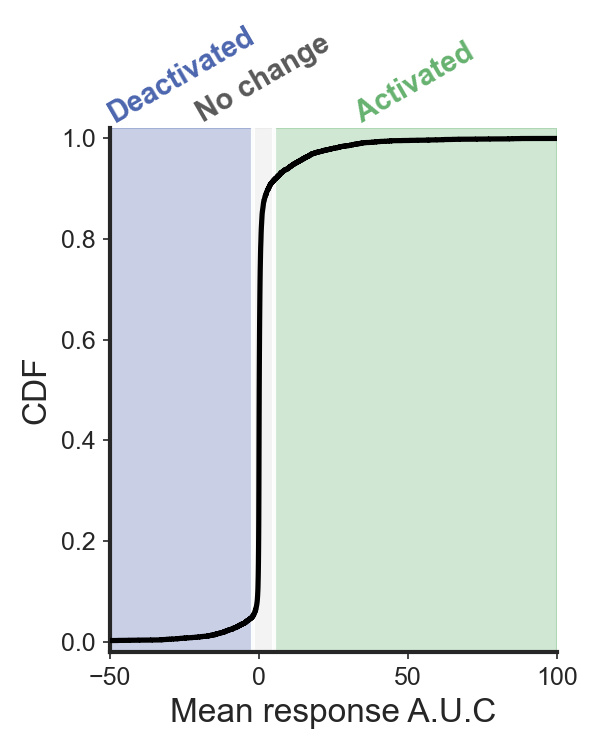

{'left_threshold': -2, 'right_threshold': 5}


In [139]:
panel_e_df = pca_plot_df.dropna(subset=["response_class", "mean_response_auc"]).copy()

fig, ax, thresholds = plot_response_auc_cdf_with_regions(
    panel_e_df,
    value_col="mean_response_auc",
    class_col="response_class",
    xlim=(-50, 100),  # optional
)

print(thresholds)
fig.tight_layout()

filen = 'CDF'
save_figure(fig,os.path.join(basepath,filen),formats=['.pdf','.png'],dpi=300)

<IPython.core.display.Javascript object>


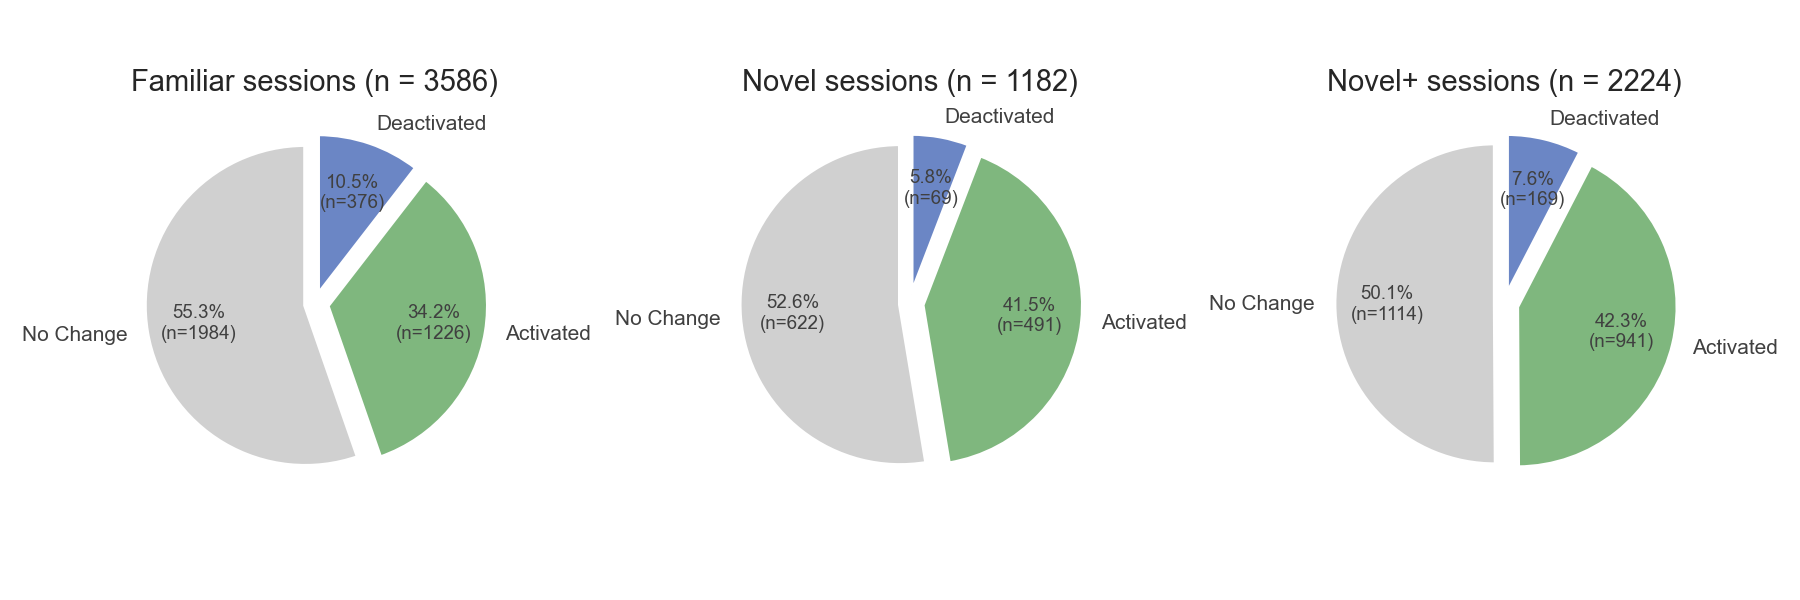

In [141]:
# Pie plots of response_class proportions by session_type
# with % and n inside wedges, class names outside

import numpy as np
import matplotlib.pyplot as plt

plot_df = pca_df.copy()
plot_df["response_class"] = (
    plot_df["response_class"]
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({
        "no-change": "no change",
        "no_change": "no change",
        "unchanged": "no change",
    })
)

session_order = ["familiar", "novel", "novel+"]
class_order = ["no change", "activated", "deactivated"]
colors = {
    "no change": "#d0d0d0",
    "activated": "#7fb77e",
    "deactivated": "#6b86c5",
}

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, session_type in zip(axes, session_order):
    sub = plot_df[plot_df["session_type"] == session_type].copy()
    counts = sub["response_class"].value_counts().reindex(class_order, fill_value=0)
    n = int(counts.sum())

    outer_labels = [cls.title() for cls in class_order]
    explode = [0.06, 0.08, 0.06]

    def autopct_factory(values):
        total = np.sum(values)
        def _autopct(pct):
            count = int(round(pct * total / 100.0))
            return f"{pct:.1f}%\n(n={count})" if count > 0 else ""
        return _autopct

    wedges, texts, autotexts = ax.pie(
        counts.values,
        labels=outer_labels,
        colors=[colors[c] for c in class_order],
        startangle=90,
        explode=explode,
        autopct=autopct_factory(counts.values),
        pctdistance=0.67,
        labeldistance=1.12,
        wedgeprops=dict(edgecolor="white", linewidth=2),
        textprops=dict(color="0.25", fontsize=10),
    )

    for t in autotexts:
        t.set_fontsize(9)
        t.set_color("0.25")

    ax.set_title(f"{session_type.title()} sessions (n = {n})", fontsize=14)

plt.tight_layout()
plt.show()

<IPython.core.display.Javascript object>


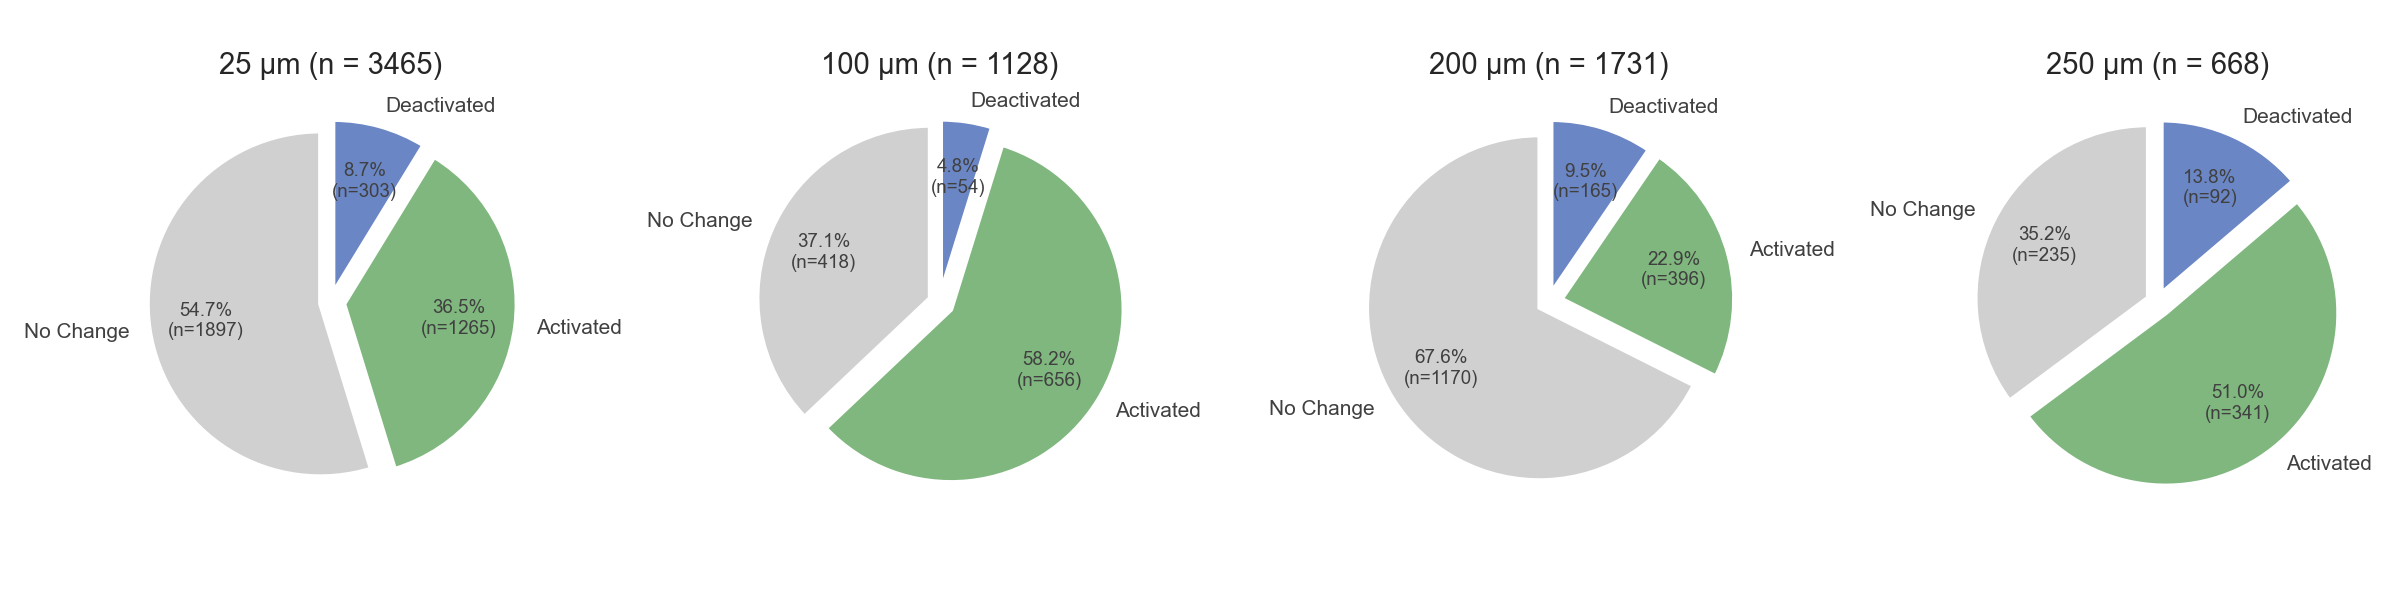

In [142]:
# Pie plots of response_class proportions by depth
# with % and n inside wedges, class names outside

import numpy as np
import matplotlib.pyplot as plt

plot_df = pca_df.copy()
plot_df["response_class"] = (
    plot_df["response_class"]
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({
        "no-change": "no change",
        "no_change": "no change",
        "unchanged": "no change",
    })
)

depth_order = [25, 100, 200, 250]
class_order = ["no change", "activated", "deactivated"]
colors = {
    "no change": "#d0d0d0",
    "activated": "#7fb77e",
    "deactivated": "#6b86c5",
}

fig, axes = plt.subplots(1, len(depth_order), figsize=(4 * len(depth_order), 4))

if len(depth_order) == 1:
    axes = [axes]

for ax, depth in zip(axes, depth_order):
    sub = plot_df[plot_df["depth"] == depth].copy()
    counts = sub["response_class"].value_counts().reindex(class_order, fill_value=0)
    n = int(counts.sum())

    outer_labels = [cls.title() for cls in class_order]
    explode = [0.06, 0.08, 0.06]

    def autopct_factory(values):
        total = np.sum(values)
        def _autopct(pct):
            count = int(round(pct * total / 100.0))
            return f"{pct:.1f}%\n(n={count})" if count > 0 else ""
        return _autopct

    wedges, texts, autotexts = ax.pie(
        counts.values,
        labels=outer_labels,
        colors=[colors[c] for c in class_order],
        startangle=90,
        explode=explode,
        autopct=autopct_factory(counts.values),
        pctdistance=0.67,
        labeldistance=1.12,
        wedgeprops=dict(edgecolor="white", linewidth=2),
        textprops=dict(color="0.25", fontsize=10),
    )

    for t in autotexts:
        t.set_fontsize(9)
        t.set_color("0.25")

    ax.set_title(f"{depth} µm (n = {n})", fontsize=14)

plt.tight_layout()
plt.show()